#  <center> Taller  de Aprendizaje Automático </center>
##  <center> Taller 8: Demanda de bicicletas compartidas. Predicciones con *Recurrent Neural Networks*  </center>

# Introducción

Las Redes Neuronales Recurrentes o *Recurrent Neural Networks* (RNN), fueron diseñadas especialmente para aprender a partir de datos secuenciales como: audio, texto, series temporales, entre muchos otros ejemplos. Para trabajar sobre algunos conceptos fundamentales de estas redes, se recurre nuevamente al conjunto de datos [*Bike Sharing Demand*](https://www.kaggle.com/c/bike-sharing-demand). Como ya se sabe estos datos cuentan con una marca de tiempo, lo cual les da un contexto temporal. Esta información es lo que va a permitir poder tratar a estos datos como secuenciales.
A nivel del problema la idea es predecir la demanda de bicicletas en el futuro a partir de una secuencia fija de datos del pasado.


## Objetivos


*   Manipular secuencias de datos.
*   Comparar diferentes enfoques de modelos de RNN para un problema concreto.   

### Cargo datos:

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [26]:
df_test = pd.read_csv('test.csv')
df_train_raw = pd.read_csv('train.csv')
df_submission = pd.read_csv('sampleSubmission.csv')

In [27]:
df_train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


# Preprocesamiento de datos

## Parte 1: Separación en conjuntos de Entrenamiento y Validación, y Rellenado de Datos Faltantes

* Del conjunto de entramiento separe un conjunto de validación. Se sugiere tomar los primeros 15 días del mes para entrenar y del día 16 al 19 para validar. (*Sugerencia:* Ajuste el código de ejemplo presentado a continuación para indexar según el día)

Este conjunto cuenta con datos faltantes lo cual es un problema que no fue tenido en cuenta en los talleres anteriores, pero sí puede ser relevante para trabajar con secuencias. La falta de datos se debe a la inexistencia de filas, tanto en el conjunto de *train* como en el conjunto de *test* (sin tener en cuenta cómo fueron divididos estos conjuntos).

*   Completar la función presentada más abajo para rellenar los datos faltantes teniendo en cuenta que se tienen datos numéricos y categóricos. (*Sugerencias:* [*pd.DataFrame.interpolate()*](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html) y [*pd.DataFrame.fillna()*](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html))


In [28]:
## Ejemplo de indexado de datos de 2012 usando atributos de datetime
años = pd.to_datetime(df_train_raw.datetime).dt.year
df_train_2012 = df_train_raw[años == 2012].reset_index(drop=True)
print(df_train_2012.shape)

(5464, 12)


In [29]:
from datetime import datetime
import calendar

# Definir las columnas categóricas y numéricas

def FilledIn(df):
    df_aux = df.copy()
    df_out = pd.DataFrame(columns=df_aux.columns)
    df_aux['datetime'] = pd.to_datetime(df_aux['datetime'])
    df_aux = df_aux.set_index('datetime')

    for year in [2011, 2012]:
      for month in range(12):
        start_date = datetime(year, month+1, 1, 0, 0, 0)
        last_day_of_month = calendar.monthrange(year, month+1)[1]
        end_date = datetime(year, month+1, last_day_of_month, 23, 0, 0)
        # Se agregan las marcas de tiempo que faltan
        df_month = df_aux[start_date:end_date]
        df_month = df_month.resample('H').asfreq()
        
        # Rellenar los datos faltantes===========

        categorical_cols = ['season', 'holiday', 'workingday', 'weather']
        numeric_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

        df_month[numeric_cols] = df_month[numeric_cols].interpolate(method='linear')

        df_month[categorical_cols] = df_month[categorical_cols].fillna(method='ffill')

        #========================================
        df_month = df_month.reset_index()

        df_out = pd.concat([df_out,df_month])
    df_out = df_out.reset_index(drop=True)
    return df_out

In [30]:
train = FilledIn(df_train_raw)
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10944 entries, 0 to 10943
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10944 non-null  datetime64[ns]
 1   season      10944 non-null  float64       
 2   holiday     10944 non-null  float64       
 3   workingday  10944 non-null  float64       
 4   weather     10944 non-null  float64       
 5   temp        10944 non-null  float64       
 6   atemp       10944 non-null  float64       
 7   humidity    10944 non-null  float64       
 8   windspeed   10944 non-null  float64       
 9   casual      10944 non-null  float64       
 10  registered  10944 non-null  float64       
 11  count       10944 non-null  float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 1.0 MB


/var/folders/md/0zfzh94s20x4r8fchz8qjg8m0000gn/T/ipykernel_65482/2083309979.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_month = df_month.resample('H').asfreq()
/var/folders/md/0zfzh94s20x4r8fchz8qjg8m0000gn/T/ipykernel_65482/2083309979.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_month[categorical_cols] = df_month[categorical_cols].fillna(method='ffill')
/var/folders/md/0zfzh94s20x4r8fchz8qjg8m0000gn/T/ipykernel_65482/2083309979.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_out = pd.concat([df_out,df_month])
/var/folders/md/0zfzh94s20x4r8fchz8qjg8m0000gn/T/ipykerne

## Parte 2: Ingeniería de características y estandarización de los datos


*   Se aplica la ingeniería de características utilizada en el Taller 3.
*   Se estandarizan los datos. Se recomienda utilizar [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) para los datos categóricos.



In [31]:
days = train['datetime'].dt.day
df_full_train = train[days <= 15]
df_full_val = train[days >= 16]

y_train = df_full_train['count']
y_val = df_full_val['count']

# Imprimir las formas de los conjuntos de datos
print("Forma del conjunto de entrenamiento:", df_full_train.shape)
print("Forma del conjunto de validación:", df_full_val.shape)

Forma del conjunto de entrenamiento: (8640, 12)
Forma del conjunto de validación: (2304, 12)


In [32]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

class TimeFeatures(BaseEstimator, TransformerMixin):
  def __init__(self):
    self
  def fit(self, X, y=None):
    # X debe ser un DataFrame
    return self
  def transform(self, X):
    X_aux = X.copy()
    X_aux['datetime'] = pd.to_datetime(X_aux['datetime'])
    X_aux['month'] = X_aux['datetime'].dt.month
    X_aux['weekday'] = X_aux['datetime'].dt.weekday
    X_aux['hour'] = X_aux['datetime'].dt.hour
    X_aux = X_aux.drop('datetime', axis=1)
    return X_aux

cat_features = ['season', 'weather', 'month', 'weekday', 'hour']
num_features = ['temp', 'atemp', 'humidity', 'windspeed']
# [holiday, workingday] ya son onehot
scaler = ColumnTransformer([('cat', OneHotEncoder(), cat_features),
                            ('num', StandardScaler(), num_features),
                            ], remainder='passthrough')

preprocess_pipe = Pipeline([('timefeatures', TimeFeatures()),
                            ('scaler', scaler)])

## df_full_train y df_full_val son los datos de entrenamiento y validación con los datos faltantes ya completados
dropeable = ['registered', 'casual', 'count']

# Drop multiple columns specified in the 'dropeable' list
df_x_train = df_full_train.copy()
print("Original shape of training data:", df_x_train.shape)
df_x_train = df_x_train.drop(columns=dropeable)
print("Shape of training data after dropping columns:", df_x_train.shape)

df_x_val = df_full_val.copy()
print("Original shape of validation data:", df_x_val.shape)
df_x_val = df_x_val.drop(columns=dropeable)
print("Shape of validation data after dropping columns:", df_x_val.shape)

# Apply the preprocessing pipeline
X_train = preprocess_pipe.fit_transform(df_x_train).toarray()
print("Shape of preprocessed training data:", X_train.shape)

X_val = preprocess_pipe.transform(df_x_val).toarray()
print("Shape of preprocessed validation data:", X_val.shape)


Original shape of training data: (8640, 12)
Shape of training data after dropping columns: (8640, 9)
Original shape of validation data: (2304, 12)
Shape of validation data after dropping columns: (2304, 9)
Shape of preprocessed training data: (8640, 57)
Shape of preprocessed validation data: (2304, 57)


## Parte 3: Secuencias
Para trabajar con modelos RNN en este tipo de problemas es necesario crear un nuevo *dataset* que incluya las secuencias de entrada al modelo y los valores de *target* para comparar las predicciones. Para esto se sugiere utilizar la función [keras.preprocessing.timeseries_dataset_from_array()](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/timeseries_dataset_from_array).

*   Crear dicho conjunto para entrenar un modelo que permita predecir la demanda de la próxima hora, dado que se conocen los datos de las últimas 24 horas. Para evitar introducir ruido en el modelo debido a los saltos entre meses por la extracción de los datos de *test*, se sugiere crear un *tf.data.Dataset* por cada mes e ir concatenandolos a medida que se los va procesando. Puede ser útil reusar el *loop* de la función *FilledIn*.

In [33]:
y_train = df_full_train[['count']]
y_train = y_train.set_index(pd.to_datetime(df_full_train['datetime']))

y_val = df_full_val[['count']]
y_val = y_val.set_index(pd.to_datetime(df_full_val['datetime']))

In [34]:
def create_sequence_datasets(X_train, y_train, X_val, y_val, dates_train, dates_val, sequence_length=24, batch_size=8):
    # Crear DataFrames para train y val
    train_df = pd.DataFrame(X_train, index=pd.to_datetime(dates_train))
    val_df = pd.DataFrame(X_val, index=pd.to_datetime(dates_val))
    
    # Asegurarse de que y_train y y_val sean Series
    y_train = y_train['count'] if isinstance(y_train, pd.DataFrame) else y_train
    y_val = y_val['count'] if isinstance(y_val, pd.DataFrame) else y_val
    
    y_train = pd.Series(y_train.values.ravel(), index=pd.to_datetime(dates_train))
    y_val = pd.Series(y_val.values.ravel(), index=pd.to_datetime(dates_val))
    
    dataset_meses_train = []
    dataset_meses_val = []

    for year in [2011, 2012]:
        for month in range(1, 13):
            start_date = datetime(year, month, 1)
            last_day_of_month = calendar.monthrange(year, month)[1]
            end_date = datetime(year, month, last_day_of_month, 23, 59, 59)
            
            # Crear df temporal para train y val
            df_month_train = train_df[start_date:end_date]
            df_month_val = val_df[start_date:end_date]
            
            # Obtener etiquetas para train y val
            y_month_train = y_train[start_date:end_date][sequence_length:]
            y_month_val = y_val[start_date:end_date][sequence_length:]
            
            if not df_month_train.empty and not y_month_train.empty:
                # Crear dataset para train
                dataset_train = keras.preprocessing.timeseries_dataset_from_array(
                    data=df_month_train.values,
                    targets=y_month_train.values,
                    sequence_length=sequence_length,
                    batch_size=batch_size,
                    shuffle=False
                )
                dataset_meses_train.append(dataset_train)
            
            if not df_month_val.empty and not y_month_val.empty:
                # Crear dataset para val
                dataset_val = keras.preprocessing.timeseries_dataset_from_array(
                    data=df_month_val.values,
                    targets=y_month_val.values,
                    sequence_length=sequence_length,
                    batch_size=batch_size,
                    shuffle=False
                )
                dataset_meses_val.append(dataset_val)
    
    # Concatenar todos los datasets mensuales
    train_concat = dataset_meses_train[0]
    for ds in dataset_meses_train[1:]:
        train_concat = train_concat.concatenate(ds)
    
    val_concat = dataset_meses_val[0]
    for ds in dataset_meses_val[1:]:
        val_concat = val_concat.concatenate(ds)
    
    return train_concat, val_concat

In [35]:
# Uso de la función
train_dataset, val_dataset = create_sequence_datasets(
    X_train, y_train, X_val, y_val, 
    df_x_train['datetime'].values, df_x_val['datetime'].values
)

# Imprimir información sobre los datasets
print("Dataset de entrenamiento:")
for x_batch, y_batch in train_dataset.take(1):
    print("  Forma de un batch de secuencias de entrada:", x_batch.shape)
    print("  Forma de un batch de objetivos:", y_batch.shape)

print("\nDataset de validación:")
for x_batch, y_batch in val_dataset.take(1):
    print("  Forma de un batch de secuencias de entrada:", x_batch.shape)
    print("  Forma de un batch de objetivos:", y_batch.shape)

Dataset de entrenamiento:
  Forma de un batch de secuencias de entrada: (8, 24, 57)
  Forma de un batch de objetivos: (8,)

Dataset de validación:


2024-06-24 12:20:08.228228: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Forma de un batch de secuencias de entrada: (8, 24, 57)
  Forma de un batch de objetivos: (8,)


2024-06-24 12:20:08.470163: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# Modelos
Para las siguientes partes se recomienda utilizar *Comet* para guardar los experimentos. Esta es una buena forma de comparar los diferentes modelos.

## Parte 4: *Naive forecasting*
De manera de tener una referencia de desempeño, en este tipo de problemas se utiliza como medida de base el desempeño de algún predictor muy simple como puede ser *Naive forecasting*. El cual simplemente predice un valor como el valor del dato anterior.

*    Calcular los valores de RMSLE y MAE para el predictor *naive forecasting* simplemente manipulando los indices del vector de *target* preprocesado (sobre los conjuntos de entrenamiento y validación).


In [112]:
#Naive forecasting
from sklearn.metrics import mean_absolute_error, mean_squared_log_error

# Función para naive forecasting
def naive_forecasting(y):
    return y[:-1], y[1:]

# Definición de la función RMSLE en TensorFlow
def TF_RMSLE(y_true, y_pred):
    first_log = tf.math.log1p(y_pred)
    second_log = tf.math.log1p(y_true)
    return tf.sqrt(tf.reduce_mean(tf.square(first_log - second_log)))

# Función para naive forecasting
def naive_forecasting(y):
    return y[:-1], y[1:]

# Aplicar naive forecasting en el conjunto de entrenamiento
y_train_pred, y_train_true = naive_forecasting(y_train)
mae_train = mean_absolute_error(y_train_true, y_train_pred)
rmsle_train_tf = TF_RMSLE(y_train_true, y_train_pred)

# Aplicar naive forecasting en el conjunto de validación
y_val_pred, y_val_true = naive_forecasting(y_val)
mae_val = mean_absolute_error(y_val_true, y_val_pred)
rmsle_val_tf = TF_RMSLE(y_val_true, y_val_pred)

# Calcular RMSLE con mean_squared_log_error (no se necesita en TensorFlow)
rmsle_train_np = np.sqrt(mean_squared_log_error(y_train_true, y_train_pred))
rmsle_val_np = np.sqrt(mean_squared_log_error(y_val_true, y_val_pred))

# Imprimir resultados
print("Resultados del Naive Forecasting:")
print(f"MAE en conjunto de entrenamiento: {mae_train}")
print(f"MAE en conjunto de validación: {mae_val}")
print(f"RMSLE en conjunto de entrenamiento (TensorFlow): {rmsle_train_tf.numpy()}")
print(f"RMSLE en conjunto de entrenamiento (NumPy): {rmsle_train_np}")
print(f"RMSLE en conjunto de validación (TensorFlow): {rmsle_val_tf.numpy()}")
print(f"RMSLE en conjunto de validación (NumPy): {rmsle_val_np}")

Resultados del Naive Forecasting:
MAE en conjunto de entrenamiento: 65.1618242852182
MAE en conjunto de validación: 66.68215371254885
RMSLE en conjunto de entrenamiento (TensorFlow): 0.6470199679468446
RMSLE en conjunto de entrenamiento (NumPy): 0.6470199679468446
RMSLE en conjunto de validación (TensorFlow): 0.6462402964453837
RMSLE en conjunto de validación (NumPy): 0.6462402964453836


## Parte 5: *Seq-to-Vector*
En esta parte se evaluará el desempeño de un modelo simple del tipo secuencia a vector (*seq-to-vector*) sobre el conjunto de la Parte 3. Este tipo de modelos son aquellos que reciben una secuencia a la entrada y devuelve un vector a la salida. Para esta parte se pretende que el mismo cuente con una sola capa recurrente de 64 unidades y una capa densa a la salida.

*   Utilizar el MSLE como función de costo. Agregar RMSLE y MAE como métricas.
*   Entrenar el modelo durante 50 épocas con un optimizador *Adam* (lr=1e-3) y manteniendo el resto de los hiperparámetros por defecto. ¿Cómo es el desempeño con respecto al modelo NF?
*   Justifique la cantidad de parámetros entrenables en base a las matrices de pesos y los vectores de bias de cada capa.


In [36]:
def RMSLE(y_true, y_pred):
    msle = tf.keras.losses.mean_squared_logarithmic_error(y_true, y_pred)
    return tf.sqrt(tf.reduce_mean(msle))

In [37]:
#Seq-to-Vec
model_sec_vect = keras.models.Sequential([
    keras.layers.SimpleRNN(64, input_shape=[None, X_train.shape[-1]]),  # Ajustar el tamaño de entrada según tus datos
    keras.layers.Dense(1, activation='relu')
])

# Compilar el modelo
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model_sec_vect.compile(loss='mean_squared_logarithmic_error', metrics=['mean_absolute_error'], optimizer=optimizer)

# Entrenar el modelo
history_sec_vect = model_sec_vect.fit(train_dataset, epochs=50, validation_data=val_dataset)

Epoch 1/50


/Users/nahuelpineyro/taa/2024/.conda/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1008/1008 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 4.3749 - mean_absolute_error: 121.9583 - val_loss: 2.9306 - val_mean_absolute_error: 168.6072
Epoch 2/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.2788 - mean_absolute_error: 110.0948 - val_loss: 2.3795 - val_mean_absolute_error: 160.5613
Epoch 3/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 2.1217 - mean_absolute_error: 105.4517 - val_loss: 2.1672 - val_mean_absolute_error: 155.1589
Epoch 4/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.0850 - mean_absolute_error: 102.8846 - val_loss: 1.4417 - val_mean_absolute_error: 142.0501
Epoch 5/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.8708 - mean_absolute_error: 86.5379 - val_loss: 1.0700 - val_mean_absolute_error: 131.1171
Epoch 6/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6619 - mean_absolute_error: 79.9059 - val_loss: 0.8627 - val_mean_absolute_error: 123.1456
Epoch 7/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6621 - mean_a

In [38]:
model_sec_vect.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,621 (92.27 KB)

 Trainable params: 7,873 (30.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,748 (61.52 KB)

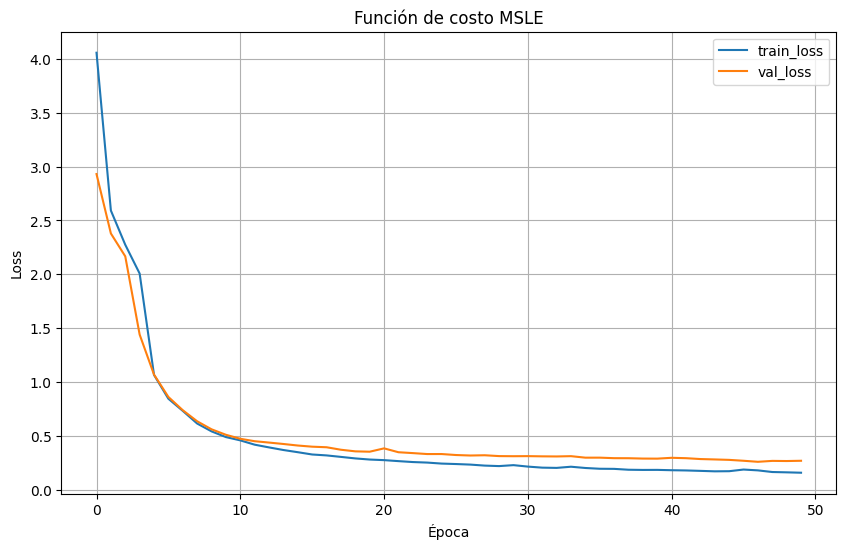

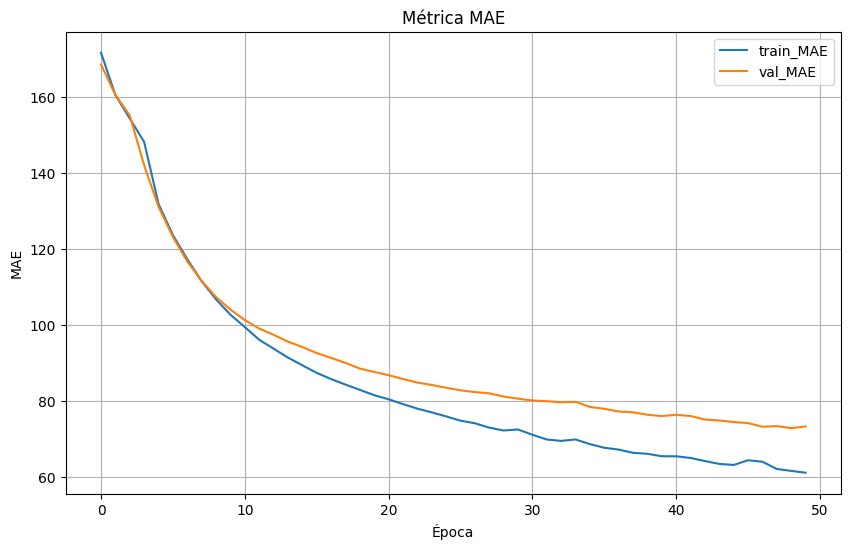

In [39]:
# Visualizar la función de costo MSLE
plt.figure(figsize=(10, 6))
plt.plot(history_sec_vect.history['loss'], label='train_loss')
plt.plot(history_sec_vect.history['val_loss'], label='val_loss')
plt.grid()
plt.legend()
plt.title('Función de costo MSLE')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.show()

# Visualizar la métrica MAE
plt.figure(figsize=(10, 6))
plt.plot(history_sec_vect.history['mean_absolute_error'], label='train_MAE')
plt.plot(history_sec_vect.history['val_mean_absolute_error'], label='val_MAE')
plt.grid()
plt.legend()
plt.title('Métrica MAE')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.show()

## Parte 6: *Seq-to-Seq*
Otro tipo de modelo para atacar el problema anterior son aquellos denominados secuencia a secuencia (*seq-to-seq*). Estos modelos reciben una secuencia a la entrada y devuelven una secuencia a la salida. Para este problema se puede utilizar este modelo para predecir el siguiente valor en cada celda de la red recurrente y no sólo en la última. De esta forma se puede mejorar el desempeño notablemente.
Antes de pasar al entrenamiento se debe modificar el *dataset* de manera que el *target* sea una secuencia de valores.
*    Adaptar el ejemplo 3 de la documentación de la función [keras.preprocessing.timeseries_dataset_from_array()](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/timeseries_dataset_from_array) para crear el nuevo *dataset*. Puede ser útil la siguiente función: *tf.data.Dataset.zip((features_dataset, labels_dataset))*.

*    Modificar el modelo anterior de manera que la salida de la red sea una secuencia, pero manteniendo el valor de los hiperparámetros.

*    Entrenar el nuevo modelo y comparar con los anteriores. ¿Por qué este modelo logra un desempeño mejor? ¿Por qué se mantiene la cantidad de parámetros entrenables?



In [40]:
import pandas as pd
from datetime import datetime
import calendar
import tensorflow as tf

def create_sequence_datasets(X_train, y_train, X_val, y_val, dates_train, dates_val, sequence_length=24, batch_size=8):
    # Crear DataFrames para train y val
    train_df = pd.DataFrame(X_train, index=pd.to_datetime(dates_train))
    val_df = pd.DataFrame(X_val, index=pd.to_datetime(dates_val))
    
    # Asegurarse de que y_train y y_val sean Series
    y_train = y_train['count'] if isinstance(y_train, pd.DataFrame) else y_train
    y_val = y_val['count'] if isinstance(y_val, pd.DataFrame) else y_val
    
    y_train = pd.Series(y_train.values.ravel(), index=pd.to_datetime(dates_train))
    y_val = pd.Series(y_val.values.ravel(), index=pd.to_datetime(dates_val))
    
    X_train_seq, y_train_seq = [], []
    X_val_seq, y_val_seq = [], []

    for year in [2011, 2012]:
        for month in range(1, 13):
            start_date = datetime(year, month, 1)
            last_day_of_month = calendar.monthrange(year, month)[1]
            end_date = datetime(year, month, last_day_of_month, 23, 59, 59)
            
            # Crear df temporal para train y val
            df_month_train = train_df[start_date:end_date]
            df_month_val = val_df[start_date:end_date]
            
            # Obtener etiquetas para train y val
            y_month_train = y_train[start_date:end_date]
            y_month_val = y_val[start_date:end_date]
            
            if not df_month_train.empty and not y_month_train.empty:
                # Crear secuencias para train
                for i in range(len(df_month_train) - sequence_length):
                    X_train_seq.append(df_month_train.iloc[i:i+sequence_length].values)
                    y_train_seq.append(y_month_train.iloc[i+1:i+1+sequence_length].values)
            
            if not df_month_val.empty and not y_month_val.empty:
                # Crear secuencias para val
                for i in range(len(df_month_val) - sequence_length):
                    X_val_seq.append(df_month_val.iloc[i:i+sequence_length].values)
                    y_val_seq.append(y_month_val.iloc[i+1:i+1+sequence_length].values)
    
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_seq)).batch(batch_size)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val_seq)).batch(batch_size)
    
    return train_dataset, val_dataset

# Uso de la función
train_dataset, val_dataset = create_sequence_datasets(
    X_train, y_train, X_val, y_val, 
    df_x_train['datetime'].values, df_x_val['datetime'].values
)

# Imprimir información sobre los datasets
print("Dataset de entrenamiento:")
for x_batch, y_batch in train_dataset.take(1):
    print("  Forma de un batch de secuencias de entrada:", x_batch.shape)
    print("  Forma de un batch de objetivos:", y_batch.shape)

print("\nDataset de validación:")
for x_batch, y_batch in val_dataset.take(1):
    print("  Forma de un batch de secuencias de entrada:", x_batch.shape)
    print("  Forma de un batch de objetivos:", y_batch.shape)


Dataset de entrenamiento:
  Forma de un batch de secuencias de entrada: (8, 24, 57)
  Forma de un batch de objetivos: (8, 24)

Dataset de validación:
  Forma de un batch de secuencias de entrada: (8, 24, 57)
  Forma de un batch de objetivos: (8, 24)


2024-06-24 12:32:17.116682: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-06-24 12:32:17.124950: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [41]:
from tensorflow import keras

# Definir el modelo secuencia a secuencia
model_seq_to_seq = keras.models.Sequential([
    keras.layers.Input(shape=(None, X_train.shape[-1])),
    keras.layers.SimpleRNN(64, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(1, activation='relu'))
])

# Compilar el modelo
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model_seq_to_seq.compile(loss='mean_squared_logarithmic_error', metrics=['mean_absolute_error'], optimizer=optimizer)

# Entrenar el modelo
history_seq_to_seq = model_seq_to_seq.fit(train_dataset, epochs=50, validation_data=val_dataset)


Epoch 1/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 4.7540 - mean_absolute_error: 121.5828 - val_loss: 2.8364 - val_mean_absolute_error: 167.3292
Epoch 2/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.2202 - mean_absolute_error: 108.4557 - val_loss: 2.3034 - val_mean_absolute_error: 158.9061
Epoch 3/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.0369 - mean_absolute_error: 103.1790 - val_loss: 1.4259 - val_mean_absolute_error: 143.7963
Epoch 4/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.8913 - mean_absolute_error: 86.8037 - val_loss: 0.9803 - val_mean_absolute_error: 129.4568
Epoch 5/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6278 - mean_absolute_error: 77.8943 - val_loss: 0.7703 - val_mean_absolute_error: 119.4784
Epoch 6/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5080 - mean_absolute_error: 71.3606 - val_loss: 0.6321 - val_mean_absolute_error: 111.5505
Epoch 7/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.432

In [43]:
model_seq_to_seq.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, None, 64)       │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, None, 1)        │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,621 (92.27 KB)

 Trainable params: 7,873 (30.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,748 (61.52 KB)

## Plots de las métricas:

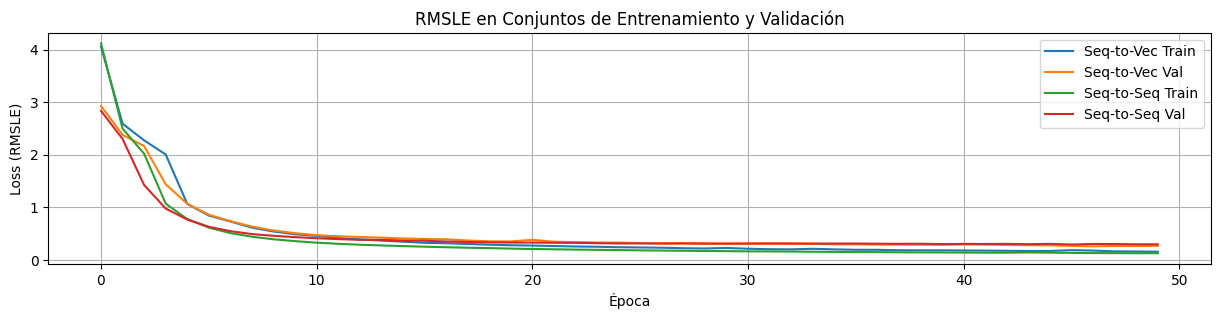

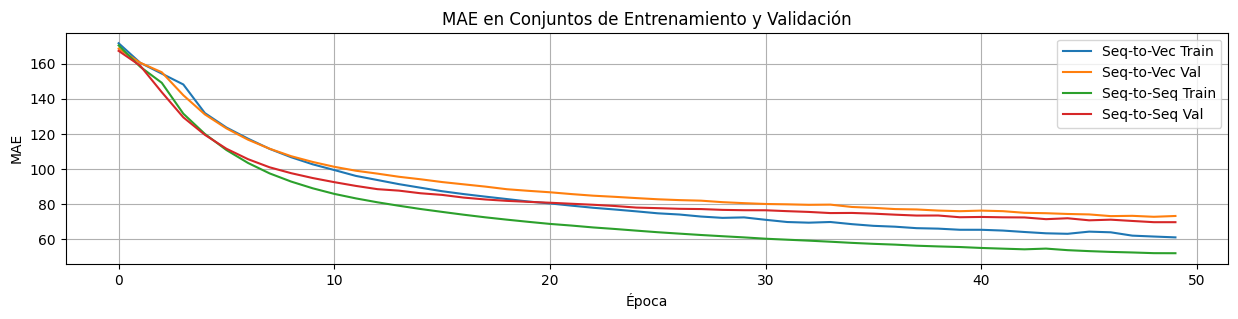

In [44]:
import matplotlib.pyplot as plt

# Gráfico 1: RMSLE para train y val - seq-to-vec vs seq-to-seq
plt.figure(figsize=(15, 3))
plt.plot(history_sec_vect.history['loss'], label='Seq-to-Vec Train')
plt.plot(history_sec_vect.history['val_loss'], label='Seq-to-Vec Val')
plt.plot(history_seq_to_seq.history['loss'], label='Seq-to-Seq Train')
plt.plot(history_seq_to_seq.history['val_loss'], label='Seq-to-Seq Val')
plt.title('RMSLE en Conjuntos de Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Loss (RMSLE)')
plt.legend()
plt.grid()
plt.show()

# Gráfico 2: MAE para train y val - seq-to-vec vs seq-to-seq
plt.figure(figsize=(15, 3))
plt.plot(history_sec_vect.history['mean_absolute_error'], label='Seq-to-Vec Train')
plt.plot(history_sec_vect.history['val_mean_absolute_error'], label='Seq-to-Vec Val')
plt.plot(history_seq_to_seq.history['mean_absolute_error'], label='Seq-to-Seq Train')
plt.plot(history_seq_to_seq.history['val_mean_absolute_error'], label='Seq-to-Seq Val')
plt.title('MAE en Conjuntos de Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid()
plt.show()


## Parte 7: LSTM
En el modelo *seq-to-seq* sustituir la capa *SimpleRNN* por una capa LSTM


*   Entrenar la red y comparar el desempeño con los modelos anteriores.
*   Justificar la cantidad de parámetros entrenables (ver la ecuación 15-3 del libro).
*   Cambiar el largo de las secuencias. ¿Cómo varía el desempeño para este modelo?
*   ¿Es posible reducir la distancia entre las curvas *train* y *validation* con los hiperparámetros *dropout* y *recurrent_dropout*?, ¿A qué parámetros afecta cada uno?.
*   (Opcional) Probar otros métodos de regularización como penalización de los pesos. Probar cambiar otros hiperparámetros de la red.


In [45]:
# Definir el modelo seq-to-seq con LSTM
model_seq_to_seq_lstm = keras.models.Sequential([
    keras.layers.Input(shape=(None, X_train.shape[-1])),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(1, activation='relu'))
])

# Compilar el modelo
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model_seq_to_seq_lstm.compile(loss='mean_squared_logarithmic_error',
                              metrics=['mean_absolute_error'],
                              optimizer=optimizer)

# Entrenar el modelo
history_seq_to_seq_lstm = model_seq_to_seq_lstm.fit(train_dataset, epochs=50, validation_data=val_dataset)

Epoch 1/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 4.6067 - mean_absolute_error: 120.6761 - val_loss: 2.7281 - val_mean_absolute_error: 165.5354
Epoch 2/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 2.1927 - mean_absolute_error: 107.2591 - val_loss: 2.2500 - val_mean_absolute_error: 157.1853
Epoch 3/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 2.0843 - mean_absolute_error: 102.9822 - val_loss: 1.9990 - val_mean_absolute_error: 150.1799
Epoch 4/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 1.2238 - mean_absolute_error: 90.9646 - val_loss: 0.9227 - val_mean_absolute_error: 127.2223
Epoch 5/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.5478 - mean_absolute_error: 74.9563 - val_loss: 0.6811 - val_mean_absolute_error: 115.1040
Epoch 6/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.4334 - mean_absolute_error: 67.9123 - val_loss: 0.5463 - val_mean_absolute_error: 105.8542
Epoch 7/50
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.365

In [46]:
model_seq_to_seq_lstm.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, None, 64)       │        31,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, None, 1)        │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,893 (366.77 KB)

 Trainable params: 31,297 (122.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,596 (244.52 KB)

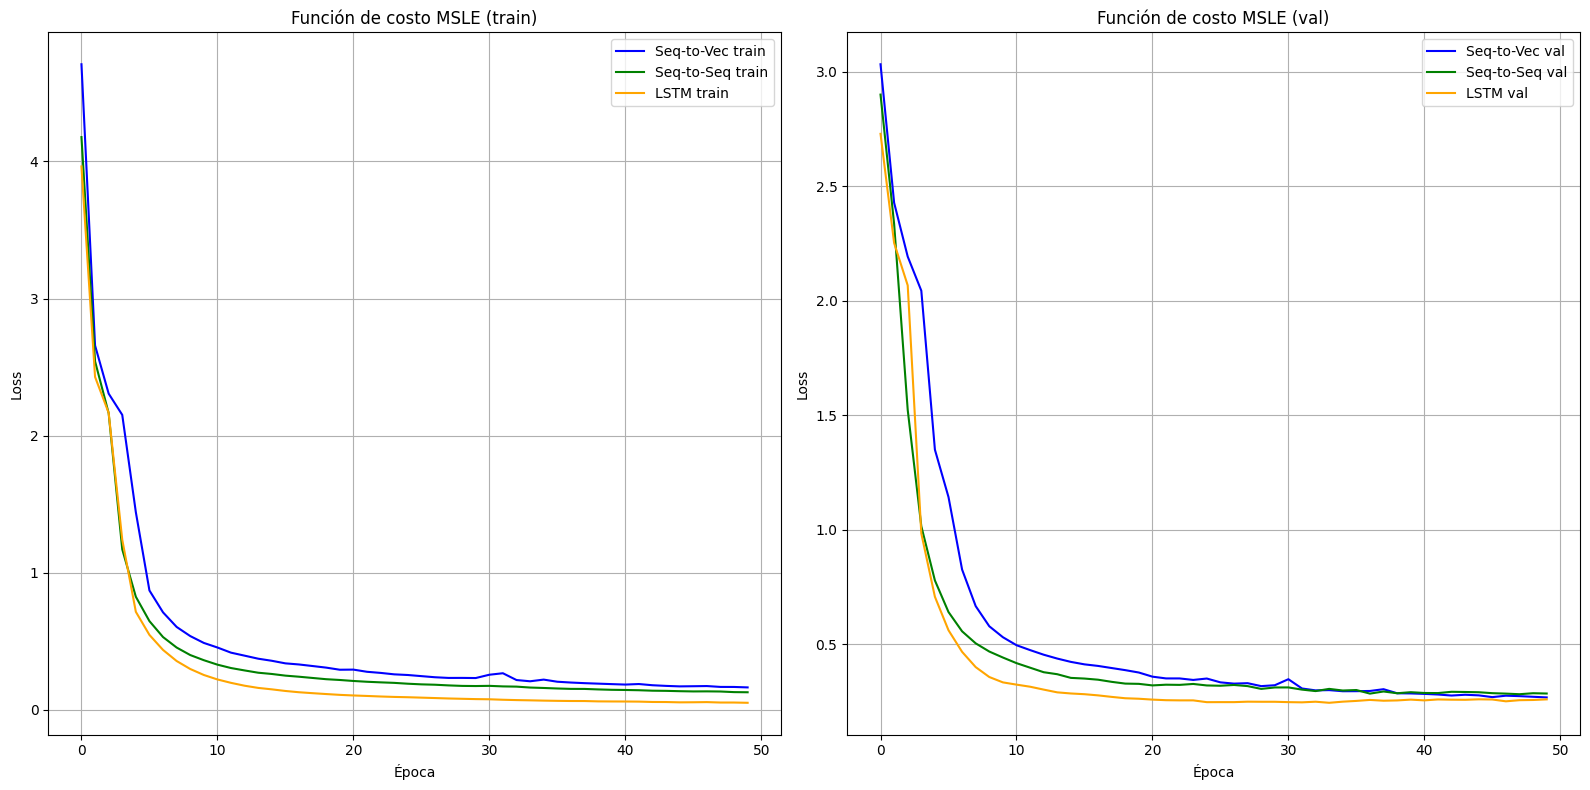

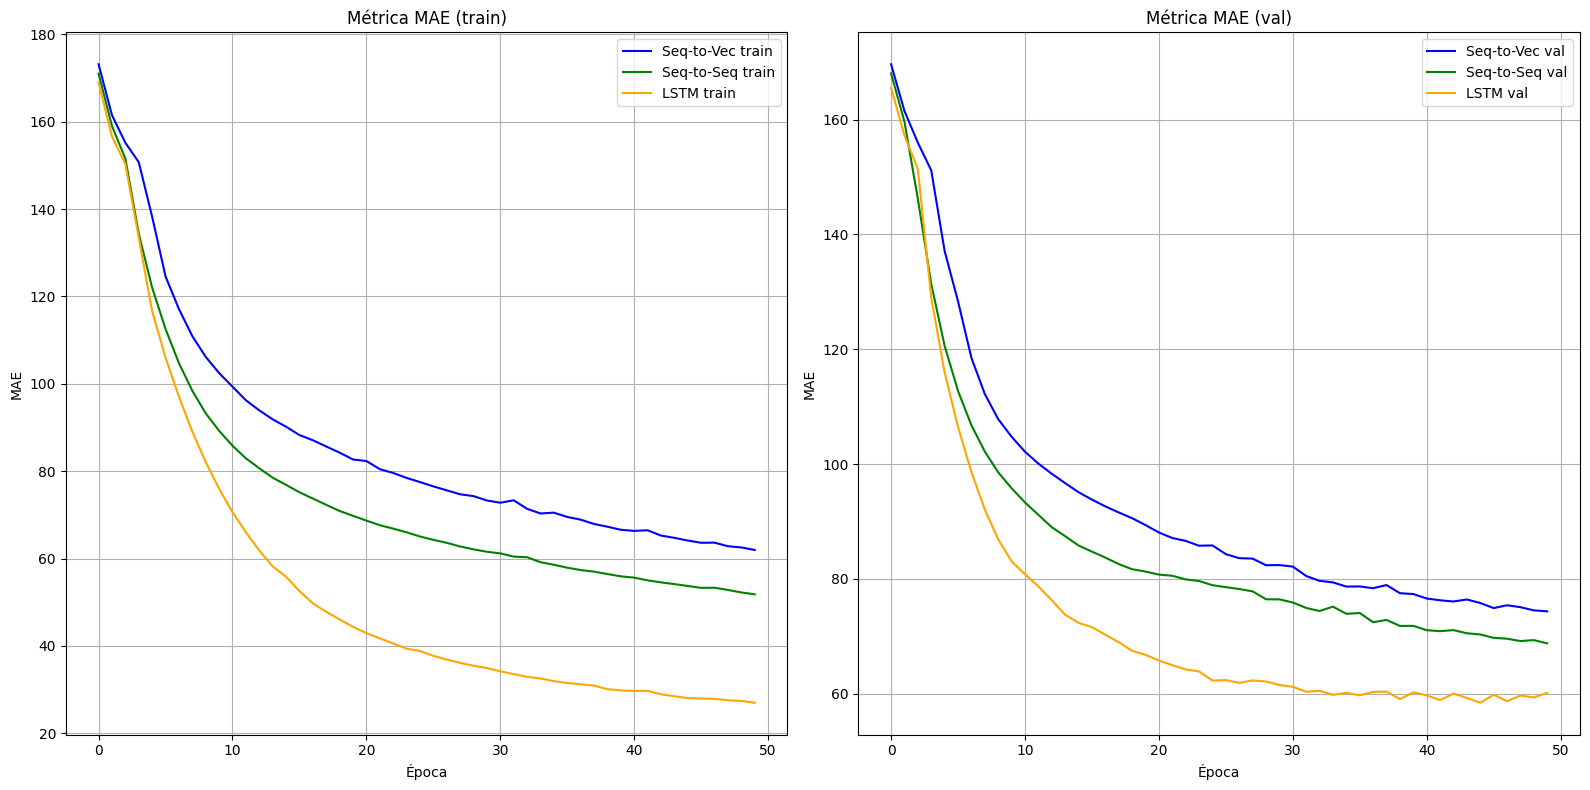

In [25]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(history_sec_vect.history['loss'], label='Seq-to-Vec train', color='blue')
plt.plot(history_seq_to_seq.history['loss'], label='Seq-to-Seq train', color='green')
plt.plot(history_seq_to_seq_lstm.history['loss'], label='LSTM train', color='orange')
plt.grid()
plt.legend()
plt.title('Función de costo MSLE (train)')
plt.xlabel('Época')
plt.ylabel('Loss')

# MSLE val vs val
plt.subplot(1, 2, 2)
plt.plot(history_sec_vect.history['val_loss'], label='Seq-to-Vec val', color='blue')
plt.plot(history_seq_to_seq.history['val_loss'], label='Seq-to-Seq val', color='green')
plt.plot(history_seq_to_seq_lstm.history['val_loss'], label='LSTM val', color='orange')
plt.grid()
plt.legend()
plt.title('Función de costo MSLE (val)')
plt.xlabel('Época')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

# Visualizar las métricas de MAE
plt.figure(figsize=(16, 8))

# MAE train vs val
plt.subplot(1, 2, 1)
plt.plot(history_sec_vect.history['mean_absolute_error'], label='Seq-to-Vec train', color='blue')
plt.plot(history_seq_to_seq.history['mean_absolute_error'], label='Seq-to-Seq train', color='green')
plt.plot(history_seq_to_seq_lstm.history['mean_absolute_error'], label='LSTM train', color='orange')
plt.grid()
plt.legend()
plt.title('Métrica MAE (train)')
plt.xlabel('Época')
plt.ylabel('MAE')

# MAE val vs val
plt.subplot(1, 2, 2)
plt.plot(history_sec_vect.history['val_mean_absolute_error'], label='Seq-to-Vec val', color='blue')
plt.plot(history_seq_to_seq.history['val_mean_absolute_error'], label='Seq-to-Seq val', color='green')
plt.plot(history_seq_to_seq_lstm.history['val_mean_absolute_error'], label='LSTM val', color='orange')
plt.grid()
plt.legend()
plt.title('Métrica MAE (val)')
plt.xlabel('Época')
plt.ylabel('MAE')

plt.tight_layout()
plt.show()

In [ ]:
model_seq_to_seq_lstm.summary()

In [121]:
# Guardar el modelo
model_seq_to_seq_lstm.save('model_seq_to_seq_lstm.h5')